# 👗 From Noise to Fashion — Image Generation with Diffusion

Welcome! This notebook walks you through building and training an **conditional image generation model** on FashionMNIST: you can tell it which clothing category to generate, and it will create new images of that type from scratch.

Today you will build the core component of the "Graphic Designer Agent" from the full AI-run magazine application. From thin air, you will be able to generate images of clothes by using a model that learns to reconstruct a corrupted image.

This should feel almost like magic! Keep in mind, though, that due to time and resource constraints we will work on much simpler scenarios. The pipeline you build today is the foundation on which modern state-of-the-art image generation models are built. Those models — such as Stable Diffusion — use the very same approach, but are trained on billions of images across ~256 high-end GPUs for several weeks.

**Pipeline:**

1. 👗 **Load the data** — Set up FashionMNIST with 10 clothing classes
2. 💨 **Forward diffusion** — Mathematically destroy images by adding Gaussian noise
3. 🔬 **Visualize the noise** — Watch a clean image dissolve into static, step by step
4. 🧠 **Train a denoising model** — Teach a UNet to predict and reverse the noise
5. 🎨 **Generate new fashion** — Sample class-conditional images from pure noise
6. 🎞️ **Watch it denoise** — Visualize the full reverse diffusion journey
7. 🌐 **Interactive web app** — Use your trained model to generate fashion on demand

By the end, you'll be able to prompt the model for any of the 10 clothing categories — giving you a hands-on look at the core technology behind modern image generation systems.

> ⚠️ **GPU STRONGLY RECOMMENDED** — Training will be very slow on CPU!
>
> Recommended runtimes in Colab: **L4** or **T4**
> - *Runtime → Change runtime type → Hardware accelerator → GPU*
> - If **L4 / T4** do not appear as options, contact a **Teaching Assistant**.

---
## 0 📦 Imports

We import PyTorch for building and training the model, torchvision for the FashionMNIST dataset, and matplotlib for visualizations.

In [1]:
#@title Fetch necessary utilities { display-mode: "form" }
!curl -O https://raw.githubusercontent.com/eth-bmai-fs26/project/refs/heads/week2-fashion-magazine-notebook/week2/notebook/utils.py


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2062  100  2062    0     0   7593      0 --:--:-- --:--:-- --:--:--  7608


In [2]:
import torch
import torch.nn.functional as F
from torch import optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import utils
import subprocess, os

device = "cpu"
if torch.cuda.is_available():           # NVIDIA GPU (Colab L4 / T4)
    device = "cuda"
elif torch.backends.mps.is_available(): # Apple M-series chip
    device = "mps"

if device == "cpu" or device == "mps":
    print("=" * 60)
    print("⚠️  WARNING: No GPU detected!")
    print("=" * 60)
else:
    print(f"✅ Using device: {device}")


✅ Using device: cuda


---
## 1 👗 Load the Data

Before we can generate fashion images, we need to show the model what fashion looks like. **FashionMNIST** contains 60,000 grayscale training images across 10 clothing categories, each 28×28 pixels.

| Label | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|-------|---|---|---|---|---|---|---|---|---|---|
| **Class** | T-shirt/top | Trouser | Pullover | Dress | Coat | Sandal | Shirt | Sneaker | Bag | Ankle boot |

We normalize each image to the range **[-1, 1]** (from raw [0, 255] pixel values). This matters for diffusion models: the noise process is defined over a zero-centered Gaussian, so keeping pixel values zero-centered keeps everything consistent.


In [3]:
IN_CHANNELS = 1
IMG_SIZE = 32
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

batch_size = 1024
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Let's look at one image to confirm
image, label = train_dataset[0]
print("Image shape:", image.shape)
print(f"Label: {label} ({CLASS_NAMES[label]})")
print(f"Pixel value range: {image.min()} to {image.max()}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.1MB/s]

Image shape: torch.Size([1, 32, 32])
Label: 9 (Ankle boot)
Pixel value range: -1.0 to 0.9058823585510254


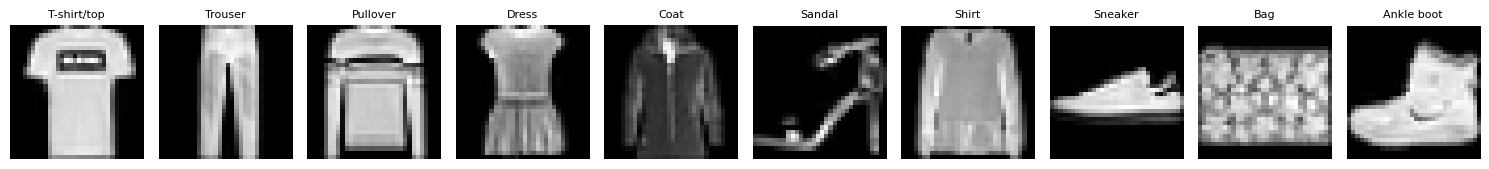

In [4]:
utils.show_class_examples(train_dataset, CLASS_NAMES)

---
## 2 💨 Forward Diffusion

The key idea behind diffusion models is elegantly destructive: take a clean image and **gradually add Gaussian noise** over many timesteps until nothing recognizable remains. Then train a neural network to reverse the process.

There is an equation that lets us corrupt an image to any noise level $i$ directly:

$$X_{i} = \sqrt{\bar{\alpha}_{i}} \, X_{0} + \sqrt{1-\bar{\alpha}_{i}} \, \varepsilon, \;\;\; \varepsilon \sim \mathcal{N}(0,I).$$

Here $\bar{\alpha}_i$ controls how much of the original image survives at timestep $i$:
- When $\bar{\alpha}_i \approx 1$ (early timesteps) — the image is nearly unchanged
- When $\bar{\alpha}_i \approx 0$ (late timesteps) — the image is almost pure Gaussian noise

> **Why is this useful?** Training samples a random timestep $t$ for every image in the batch. This formula lets us jump directly to any noise level — making training fast.

In [5]:
# Hyperparameters for the diffusion process
TIMESTEPS = 1_000
beta_start = 0.0001
beta_end = 0.02

# Define the beta schedule (variance)
betas = torch.linspace(beta_start, beta_end, TIMESTEPS, device=device)

# Pre-calculate alphas and other values for the formula
alphas = 1. - betas
alphas_bar = torch.cumprod(alphas, dim=0) # Computes comulative product of alphas

sqrt_alphas_bar = torch.sqrt(alphas_bar)
sqrt_one_minus_alphas_bar = torch.sqrt(1. - alphas_bar)

# Helper function to get the correct values for a batch of timesteps
def get_values_at_timestep(values, t):
    """
    Gathers the values from the `values` tensor at the indices specified by `t`.
    Reshapes the output to be compatible for broadcasting with image tensors.
    """
    batch_size = t.shape[0]
    # Gather values and reshape to (batch_size, 1, 1, 1) for broadcasting
    return values.gather(-1, t).reshape(batch_size, 1, 1, 1)

### 🎯 2.1 — Implement the forward noising function

Complete the `add_noise` function by filling in the three missing values.

> 💡 Hints:
> - Use `get_values_at_timestep` to extract precomputed values at timestep `t`, e.g. `a_t = get_values_at_timestep(a, t)`
> - The formula to corrupt an image to noise level $t$ is: $X_t = \sqrt{\bar{\alpha}_t} \, X_0 + \sqrt{1 - \bar{\alpha}_t} \, \varepsilon$
> - The two precomputed tensors you need are `sqrt_alphas_bar` and `sqrt_one_minus_alphas_bar`

In [8]:
# The Forward Noising Function
def add_noise(x_0, t):
    """
    Applies noise to an image x_0 at a specific timestep t.

    Args:
        x_0: The original image tensor
        t: timestep tensor

    Returns:
        x_t: The noisy image at timestep t
        noise: The noise that was added to the image
    """
    # Sample random noise from a standard Gaussian
    noise = torch.randn_like(x_0)

    # 🎯 Get the pre-calculated values for the given timesteps
    sqrt_alphas_bar_t = get_values_at_timestep(sqrt_alphas_bar, t)
    sqrt_one_minus_alphas_bar_t = get_values_at_timestep(sqrt_one_minus_alphas_bar, t)

    # 🎯 Apply the formula to get the noisy image
    x_t = x_0 *sqrt_alphas_bar_t + noise * sqrt_one_minus_alphas_bar_t

    # 🎯
    return x_t, noise

---
## 3 🔬 Visualize the Noising Process

Let's see the forward process in action. We'll take a single image and plot it at 10 evenly-spaced timesteps from $t=0$ (clean) to $t=T-1$ (pure noise).

**What to look for:**
- **Early timesteps** — The original image is clearly recognizable, just slightly grainier
- **Middle timesteps** — Fine details blur; shapes start to melt into the background
- **Late timesteps** — The image is unrecognizable — pure Gaussian noise

This progression is exactly what the model has to *undo* during generation.

### 🎯 3.1 — Visualize the noising process

Run the cell below to apply `add_noise` at 10 evenly-spaced timesteps and plot the results.

> 💡 What to check: the image should be nearly clean at $t=0$ and indistinguishable from random noise by $t=999$. If it looks wrong, revisit your `add_noise` implementation.

Visualizing the forward noising process:


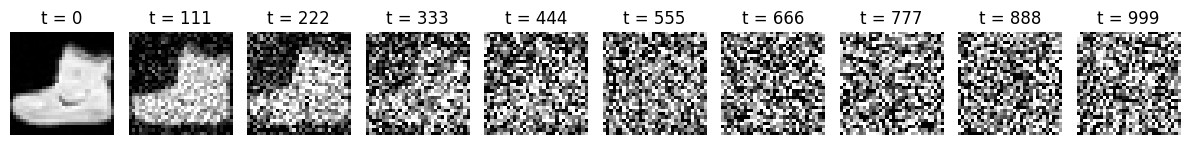

In [9]:
# Visualization of the forward pass
image, _ = train_dataset[0] # Get first image
image = image.to(device).unsqueeze(0) # Add batch dimension and move to device

num_steps = 10  # Number of noise levels to visualize
vis_timesteps = torch.linspace(0, TIMESTEPS - 1, num_steps).long().tolist()
noisy_images = []
titles = []

# Generate noisy images at specified timesteps
for timestep in vis_timesteps:
    t = torch.tensor([timestep], device=device) # Convert to tensor and move to device

    # 🎯 Use add_noise to corrupt the image
    noisy_img, _ = add_noise(image, t)

    noisy_images.append(noisy_img)
    titles.append(f"t = {timestep}")

print("Visualizing the forward noising process:")
utils.show_images(torch.cat(noisy_images, dim=0), titles=titles)

---
## 4 🧠 Reverse Diffusion — Training the Denoiser

Now for the clever part. We've seen how to *destroy* an image. The question is: can a neural network learn to *reverse* this process?

The answer is yes — by training a **UNet** to predict the noise $\varepsilon$ that was added at each timestep. If the model can accurately estimate the noise, it can subtract it to recover a slightly cleaner image. Repeat 1,000 times starting from pure static, and a coherent image emerges.

The model is **class-conditional**: we pass the clothing category label alongside the noisy image, so the model learns to reverse noise in a class-aware way. This is how you steer generation toward a specific category at sampling time.

### 4.1 🎯-🏗️ Define the UNet

`SimpleUNet` is a lightweight UNet with skip connections. It takes a noisy image $x_t$, the timestep $t$, and the class label as inputs, and outputs a **predicted noise tensor of the same shape**.

The training objective is simple: minimize the MSE between the predicted noise and the actual noise that was added. This is the core of the DDPM training algorithm.

| Input | What it is |
|-------|------------|
| `x_t` | The noisy image at timestep $t$ |
| `t` | The timestep — tells the model how noisy the input is |
| `labels` | The class label — steers denoising toward a specific category |

In [14]:
import math
import torch.nn as nn

class SimpleUNet(nn.Module):
    """
    A simple UNet with Class Conditioning.

    args:
    - base_ch: number of channels in the first layer (doubles every downsample)
    - emb_dim: dimension of the time and class embedding
    - num_classes: number of classes for conditioning
    - in_channels: number of input image channels (1=grayscale, 3=RGB)

    note: output channels are always the same as input channels, since we're predicting noise which has the same shape as the input image.
    """
    def __init__(self, base_ch=64, emb_dim=64, num_classes=10, in_channels=1):
        super().__init__()

        self.base_ch = base_ch
        self.emb_dim = emb_dim

        # 🎯 Fill in input and output channels
        self.in_ch = in_channels
        self.out_ch = in_channels


        # This learns a unique vector of size 'emb_dim' for each class (0-9).
        self.label_emb = nn.Embedding(num_classes, emb_dim)

        # This MLP combines the time and label embeddings into a single conditioning embedding that will be used in the ConvBlocks.
        self.cond_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 2),
            nn.SiLU(),
            nn.Linear(emb_dim * 2, emb_dim),
        )

        # ↘️ Encoder --------------------------------------------------------------------------------------
        self.enc1 = ConvBlock(self.in_ch, base_ch, emb_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)

        # 🎯 Fill enc2 and down2
        # Hint: recall that in enc, the number of output channels is double the number of input channels
        # Hint: in the downsample, you can keep the same number of filter size, stride, and padding as down1
        self.enc2 = ConvBlock(base_ch, base_ch * 2, emb_dim)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, stride=2, padding=1)

        # 🎯 Fill enc3 and down3
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4, emb_dim)
        self.down3 = nn.Conv2d(base_ch * 4, base_ch * 4, 4, stride=2, padding=1)
        # End of encoder --------------------------------------------------------------------------------

        # 🪢 Bottleneck
        # 🎯 Fill the bottleneck layer
        # Hint: use a ConvBlock, with the same number of input and output channels
        self.bot = ConvBlock(base_ch * 4, base_ch * 4, emb_dim)

        # ↗️ Decoder --------------------------------------------------------------------------------------
        self.up3 = nn.ConvTranspose2d(base_ch * 4, base_ch * 4, 4, stride=2, padding=1)
        self.dec3 = ConvBlock(base_ch * 4 + base_ch * 4, base_ch * 2, emb_dim)

        # 🎯 Fill up2 and dec2
        # Hint: in the upsample, you can keep the same number of filter size, stride, and padding as up3
        # Hint: for dec2, don't forget to account for the skip connection
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch *2, 4, stride=2, padding=1)
        self.dec2 = ConvBlock(base_ch * 2 + base_ch * 2, base_ch, emb_dim)

        # 🎯 Fill up1 and dec1
        # Hint: in dec 1, don't forget to account for the skip connection
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, stride=2, padding =1)
        self.dec1 = ConvBlock(base_ch + base_ch, base_ch, emb_dim)
        # End of decoder --------------------------------------------------------------------------------------

        self.out = nn.Conv2d(base_ch, self.out_ch, 1)

    def forward(self, x, t, labels):
        """
        x: (B, C, H, W)
        t: (B,)
        labels: (B,) IntTensor containing class indices (0-9)
        """
        # create time and label embeddings and combine them into a single conditioning embedding
        time_emb = sinusoidal_time_embedding(t, self.emb_dim)
        label_emb = self.label_emb (labels)   # 🎯 Create the label embedding using self.label_emb
        cond_emb = self.cond_mlp(time_emb + label_emb)  # 🎯 Sum time and label embeddings and pass through self.cond_mlp

        # ↘️ encoder
        e1 = self.enc1(x, cond_emb)
        d1 = self.down1(e1)

        # 🎯 Use self.enc2 and self.down2 to go one level deeper
        # Hint: recall that enc2 takes the output of down1 as input
        e2 = self.enc2(d1, cond_emb)
        d2 = self.down2(e2)

        # 🎯 Use self.enc3 and self.down3 to go one level deeper
        e3 = self.enc3(d2, cond_emb)
        d3 = self.down3(e3)

        # 🪢 bottleneck
        b = self.bot(d3, cond_emb)

        # ↗️decoder
        u3 = self.up3(b)
        u3 = torch.cat([u3, e3], dim=1)     # skip connection: concatenate the upsampled features with the corresponding encoder features
        u3 = self.dec3(u3, cond_emb)

        # 🎯 Fill up2 and dec2
        # Hint: in up2, input is the output of dec3
        u2 = self.up2(u3)
        u2 = torch.cat([u2, e2], dim=1)
        u2 = self.dec2 (u2, cond_emb)

        # 🎯 Fill up1 and dec1
        u1 = self.up1(u2)
        u1 = torch.cat([u1, e1], dim=1)
        u1 = self.dec1(u1, cond_emb)

        return self.out(u1)

class ConvBlock(nn.Module):
    """
    Two convolutional layers followed by FiLM conditioning.

    FiLM (Feature-wise Linear Modulation) lets the network behave differently
    depending on the timestep and class, by scaling and shifting the feature map:

        output = features * (1 + scale) + shift

    where scale and shift are predicted from the conditioning embedding.
    """
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.SiLU(),
        )
        # 🎯 predict per-channel scale and shift from the conditioning embedding
        # Hint: use 2 identical linear layers, one for scale and one for shift
        # Hint: input dimension is dim of the conditioning embedding, output dimension is the number of output channels
        self.to_scale = nn.Linear(emb_dim, out_ch)
        self.to_shift = nn.Linear(emb_dim, out_ch)

    def forward(self, x, cond_emb):
        # First we apply the convolutional layers to get the features
        h = self.conv(x)

        # Then we predict the scale and shift from the conditioning embedding
        scale = self.to_scale(cond_emb).unsqueeze(-1).unsqueeze(-1)
        shift = self.to_shift(cond_emb).unsqueeze(-1).unsqueeze(-1)

        # 🎯 Finally we apply a modulation to the features using the predicted scale and shift
        # You can think of this as the network saying "at this timestep and for this class, I want to amplify these features and suppress these other features"
        # Hint: output = features * (1 + scale) + shift
        return h * (1+ scale ) + shift

# NO EDIT ARE NEEDED BELOW THIS LINE (for this cell)
def sinusoidal_time_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    """
    Transformer-style sinusoidal positional encoding for diffusion timesteps.
    This is needed because the model needs to know which timestep it's at in order to predict the noise correctly.

    timesteps: (B,) long
    returns:   (B, dim)
    """
    device = timesteps.device
    half = dim // 2
    emb = math.log(10000) / (half - 1)
    emb = torch.exp(torch.arange(half, device=device) * -emb)
    emb = timesteps.float().unsqueeze(1) * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb  # (B, dim)

### 4.2 🎯-🏋️ Train the UNet

Now that we have defined our denoising autoencoder, we can train it. For each batch we sample a random timestep $t$, corrupt the images with the corresponding noise level, and ask the model to predict that noise. The loss is simply the MSE between predicted and actual noise.

In [15]:

# --- Initialize the model which we use to predict the noise.
denoising_model = SimpleUNet(base_ch=64, emb_dim=64, num_classes=NUM_CLASSES, in_channels=IN_CHANNELS).to(device)
denoising_model.train()
optimizer = optim.AdamW(denoising_model.parameters(), lr=2e-4)

# --- Training loop, learning to reverse the noise. ---
epochs = 30

for epoch in range(1, epochs + 1):
    for x_0, labels in train_loader:
        optimizer.zero_grad(set_to_none=True)
        x_0 = x_0.to(device)
        labels = labels.to(device)
        batch_dimension = x_0.size(0)
        t = torch.randint(0, TIMESTEPS, (batch_dimension,), device=device).long() # choose random timestep for every sample from the input

        # 🎯 Add noise using the forward process (Hint: you already implemented this in exercise 3.1)
        x_t, noise = add_noise(x_0, t)

        # 🎯 Predict the added noise, conditioned on the class label
        # Hint: pass the noisy image, timesteps, and labels into the denoising model
        predicted_noise = denoising_model(x_t, t, labels)

        # 🎯Compute the (mean squared error) loss between the predicted_noise and the real noise
        # Hint: use F.mse_loss to compute the MSE loss
        loss = F.mse_loss (predicted_noise, noise)

        # 🎯 Backward pass and optimization step
        loss.backward()
        optimizer.step()

    if epoch%1 == 0:
        print(f"Finished epoch {epoch}. Current loss: loss={loss.item():.4f}")

print("Training is finished!")

Finished epoch 1. Current loss: loss=0.1236
Finished epoch 2. Current loss: loss=0.0669
Finished epoch 3. Current loss: loss=0.0561
Finished epoch 4. Current loss: loss=0.0591
Finished epoch 5. Current loss: loss=0.0479
Finished epoch 6. Current loss: loss=0.0426
Finished epoch 7. Current loss: loss=0.0444
Finished epoch 8. Current loss: loss=0.0326
Finished epoch 9. Current loss: loss=0.0364
Finished epoch 10. Current loss: loss=0.0372
Finished epoch 11. Current loss: loss=0.0390
Finished epoch 12. Current loss: loss=0.0355
Finished epoch 13. Current loss: loss=0.0402
Finished epoch 14. Current loss: loss=0.0328
Finished epoch 15. Current loss: loss=0.0381
Finished epoch 16. Current loss: loss=0.0387
Finished epoch 17. Current loss: loss=0.0303
Finished epoch 18. Current loss: loss=0.0284
Finished epoch 19. Current loss: loss=0.0366
Finished epoch 20. Current loss: loss=0.0332
Finished epoch 21. Current loss: loss=0.0281
Finished epoch 22. Current loss: loss=0.0325
Finished epoch 23. 

### 4.2 🔁 The Sampling Equations

Training taught the model to estimate noise. Now we use that estimate to iteratively denoise, stepping **backwards** from $t=T$ (pure noise) to $t=0$ (clean image).

**Here is the key idea:** at each step $i$, we ask the trained UNet *"what noise do you think was added to this image?"* — that predicted noise is $\bar{\varepsilon}_{i}$. We then subtract it to get a slightly cleaner image, and repeat 1,000 times.

---

**Step 1 — Estimate the clean version (posterior mean)**

$$\mu(x_i) = \frac{1}{\sqrt{\alpha_i}} \left( x_i - \frac{1-\alpha_i}{\sqrt{1 - \bar{\alpha}_{i}}} \underbrace{\bar{\varepsilon}_{i}}_{\text{UNet output}} \right)$$

$\mu(x_i)$ is our best guess for what the image looks like with *a little less noise* — one small step closer to the final clean image. The UNet's job is to fill in $\bar{\varepsilon}_{i}$: it looks at the current noisy image and predicts what noise was mixed in.

---

**Step 2 — Add a pinch of randomness**

If we always took the exact mean, every generation run would produce the same image. To keep outputs diverse, we add a small random kick:

$$x_{i-1} = \mu(x_i) + \underbrace{\sigma(i) \cdot z}_{\text{diversity noise}}$$

where $z$ is fresh random noise and $\sigma(i)$ scales it down (it shrinks to zero at the final step so the last image isn't noisy).

---

> **In plain English:** start from static. At each step, the UNet looks at the current blurry mess and says *"I think this noise was added"*. We remove most of it, add just a tiny bit of fresh randomness for variety, and repeat — until a recognizable garment emerges.

---
## 5 🎨 Generate New Fashion

Training is done — now comes the fun part. We sample new images by starting from **pure Gaussian noise** and running the reverse diffusion process around a 1000 steps, guided by the trained UNet.

Because the model is class-conditional, we can ask it to generate any of the 10 clothing categories. Change `class_label` to any number from 0 to 9 and watch the model invent a new garment from static.

In [16]:
# Precompute helpful buffers for sampling
alphas_bar_previous = torch.cat([torch.tensor([1.0], device=device), alphas_bar[:-1]], dim=0)
sqrt_alphas_inverse = torch.sqrt(1.0 / alphas)
inverse_sqrt_one_minus_alphas_bar = torch.sqrt(1.0 - alphas_bar)

# Posterior mean coefficient
coef_eps = (1 - alphas) / inverse_sqrt_one_minus_alphas_bar

# Posterior variance
posterior_variance = (1 - alphas) * (1 - alphas_bar_previous) / (1 - alphas_bar)
posterior_log_variance_clipped = torch.log(torch.clamp(posterior_variance, min=1e-20))

### 🎯 5.1 — Implement the denoising step

Complete the `mean` computation inside `sample`. This is the model's best estimate of a slightly cleaner image at each reverse step.

> 💡 Hints:
> - The formula is: $\mu(x_t) = \dfrac{1}{\sqrt{\alpha_t}} \left( x_t - \dfrac{1-\alpha_t}{\sqrt{1 - \bar{\alpha}_{t}}} \cdot \varepsilon \right)$
> - `coef_eps[timestep]` gives you $\dfrac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}$, and `sqrt_alphas_inverse[timestep]` gives you $\dfrac{1}{\sqrt{\alpha_t}}$
> - `denoising_model(x_t, t, labels)` is $\varepsilon$ — the noise predicted by the UNet

In [17]:
@torch.no_grad()
def sample(denoising_model, num_samples=16, class_label=0):
    denoising_model.eval()
    # Start from random noise
    x_t = torch.randn(num_samples, IN_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)

    # Class label tensor — same label for all samples in this batch
    labels = torch.full((num_samples,), class_label, device=device, dtype=torch.long)

    # Now we reverse the noising
    for timestep in reversed(range(TIMESTEPS)):
        t = torch.full((num_samples,), timestep, device=device, dtype=torch.long)

        # 🎯 Denoise the image
        # Hint: use the formula and the hints above
        # Hint: epsilon (the predicted noise) is given by the output of the denoising model
        epsilon = denoising_model(x_t, t, labels)
        mean = (1/sqrt_alphas_inverse[timestep]) * (x_t - coef_eps[timestep] * epsilon)

        if timestep > 0:
            #Add noise for sample diversity
            noise = torch.randn_like(x_t)
            var = posterior_variance[timestep]

            # 🎯 Compute x_{t-1} using the mean, var and noise
            # Hint: recall that we need to torch.sqrt() the variance when adding noise
            x_t = mean + torch.sqrt(var) * noise
        else:
            # 🎯 Compute final x_t, here we don't add noise
            x_t = mean
    return x_t

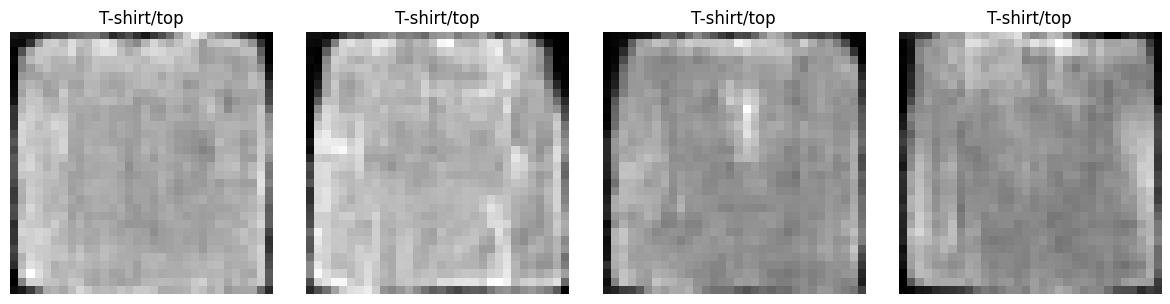

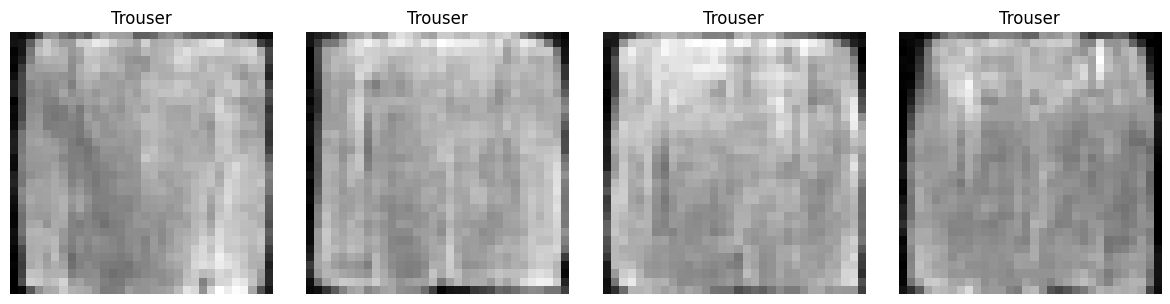

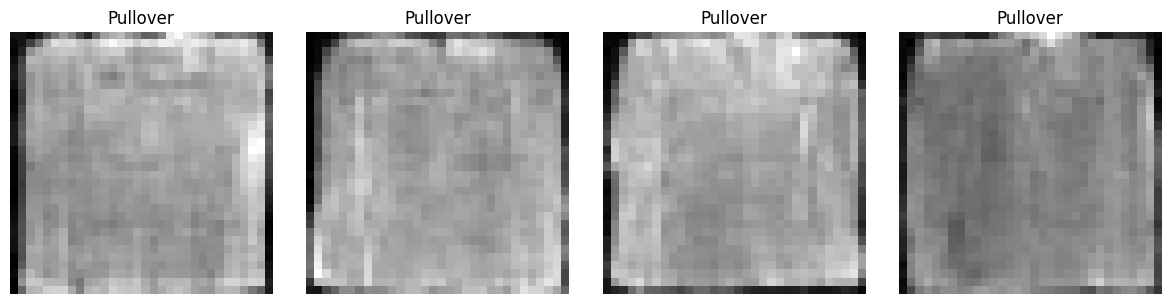

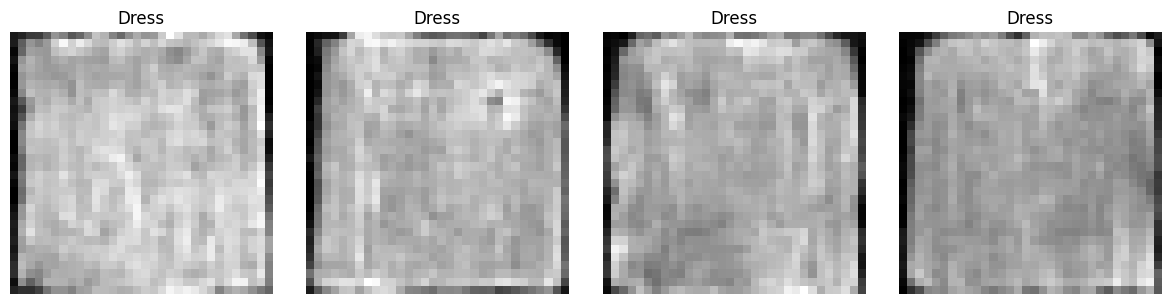

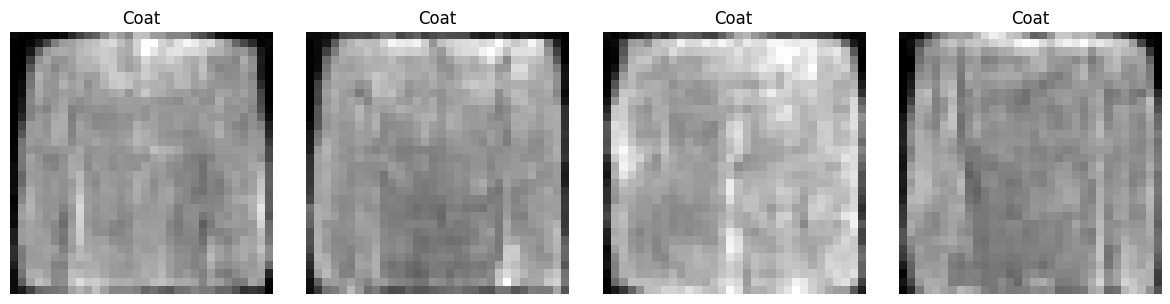

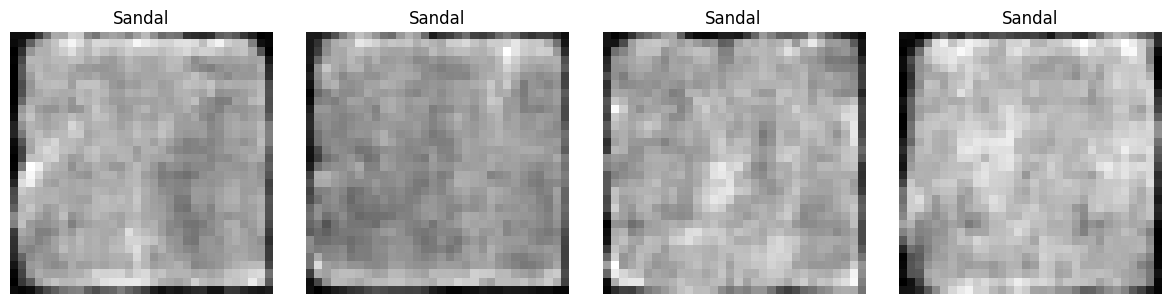

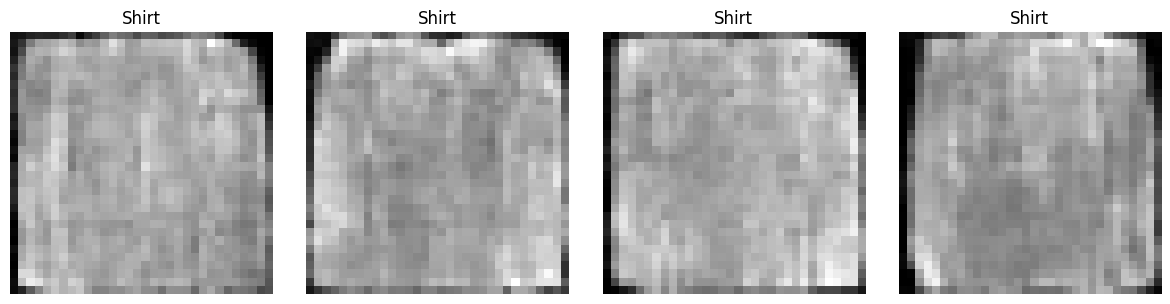

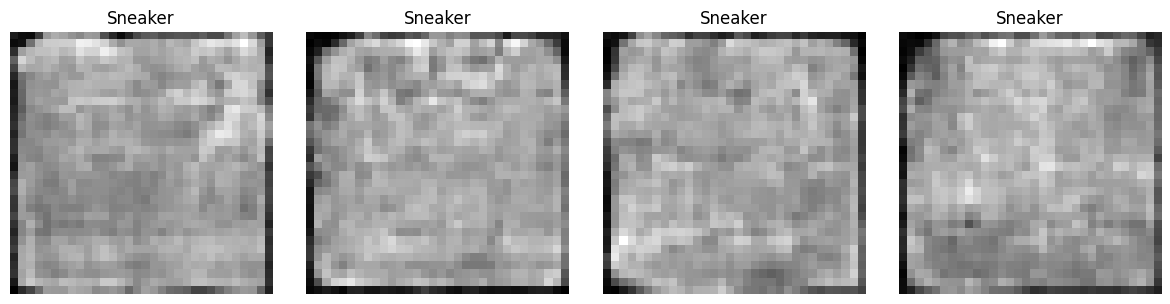

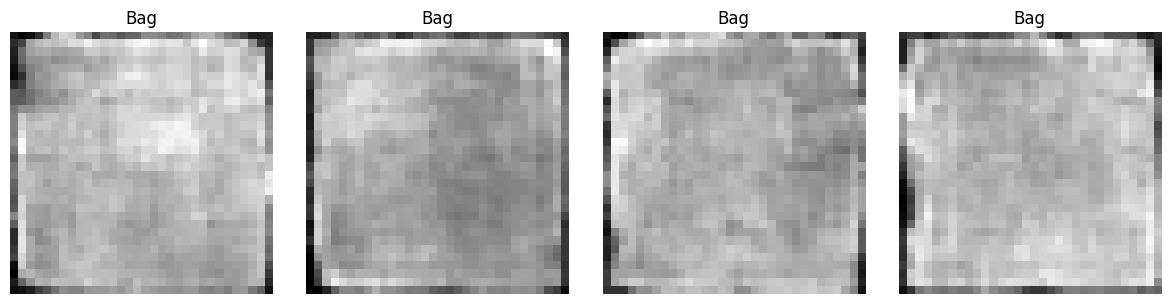

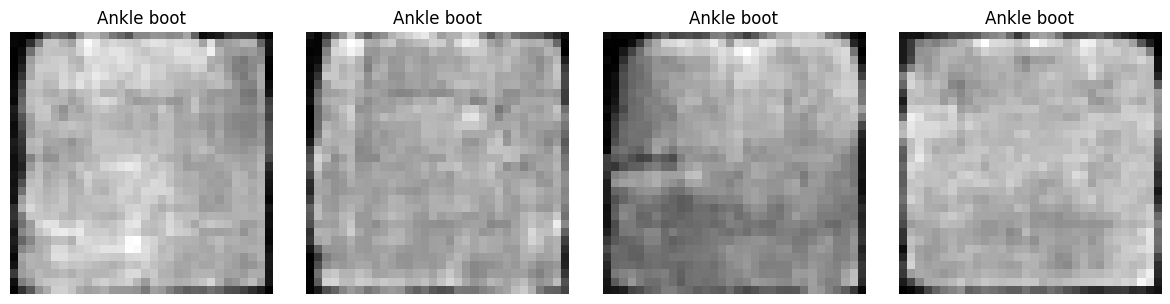

In [18]:
#@title Display Samples { display-mode: "form" }
for class_label in range(NUM_CLASSES):
    samples = sample(denoising_model, num_samples=4, class_label=class_label)
    utils.show_images(samples.cpu(), titles=[CLASS_NAMES[class_label]] * 4)

---
## 6 🎞️ Watch It Denoise

A single image, visualized at 10 checkpoints across the full denoising journey — from pure noise all the way to the finished garment.

**What to look for:**
- **High $t$** — Indistinguishable static; the model is just getting started
- **Mid $t$** — Rough shapes and outlines begin to emerge
- **Low $t$** — Fine texture and detail snap into place in the final steps

This is the reverse of Section 3 — the same 10-step window, but running backwards.

In [19]:
@torch.no_grad()
def denoising_process_single_sample(
    denoising_model,
    class_label: int = 0,                         # which class to generate
    record_timesteps: list[int] | None = None,    # which t to keep (e.g., [TIMESTEPS-1,...,0]); None = keep all
):
    denoising_model.eval()

    x_t = torch.randn(1, IN_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    start_t = TIMESTEPS - 1

    # Class label tensor (batch size 1)
    labels = torch.tensor([class_label], device=device, dtype=torch.long)

    record_set = set(record_timesteps) if record_timesteps is not None else None
    trace = []

    # Optionally record the starting x_T
    if record_set is None or start_t in record_set:
        trace.append((start_t, x_t.detach().clone()))

    for timestep in reversed(range(TIMESTEPS)):
        t = torch.full((1,), timestep, device=device, dtype=torch.long)

        # mean term: (x - coef_eps_i * eps_theta) / sqrt(alpha_i), conditioned on class
        mean = (x_t - coef_eps[timestep] * denoising_model(x_t, t, labels)) * sqrt_alphas_inverse[timestep]

        if timestep > 0:
            noise = torch.randn_like(x_t)
            var = posterior_variance[timestep]
            x_t = mean + torch.sqrt(var) * noise
        else:
            x_t = mean  # final step has no noise

        if record_set is None or timestep in record_set:
            trace.append((timestep, x_t.detach().clone()))

    # trace is in descending t order already (T-1 -> 0)
    return x_t, trace

Class 0: T-shirt/top


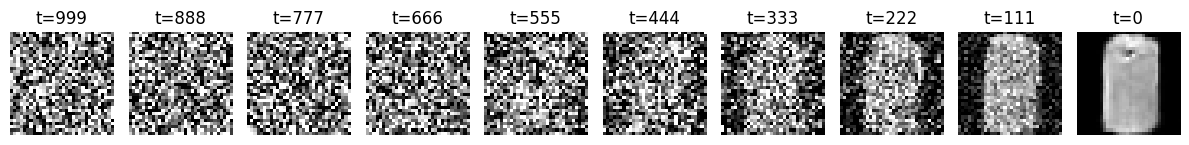

Class 1: Trouser


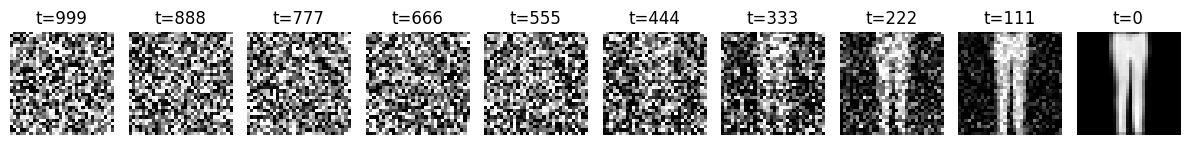

Class 2: Pullover


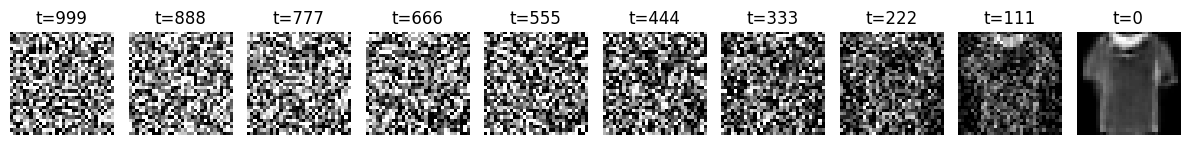

Class 3: Dress


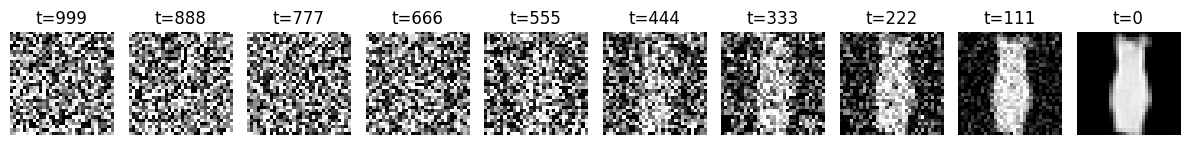

Class 4: Coat


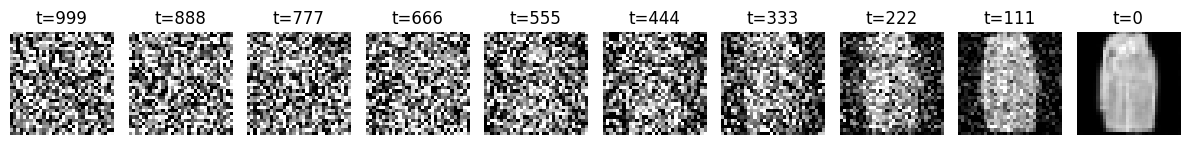

Class 5: Sandal


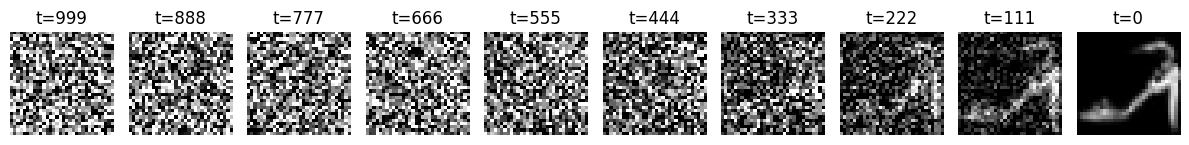

Class 6: Shirt


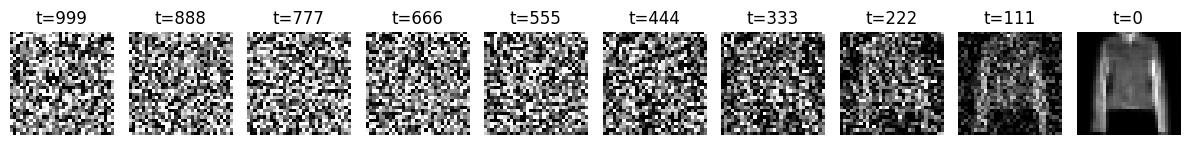

Class 7: Sneaker


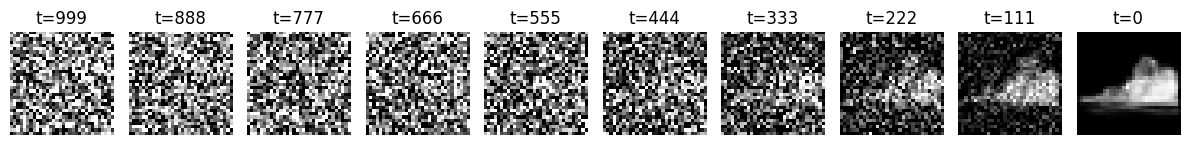

Class 8: Bag


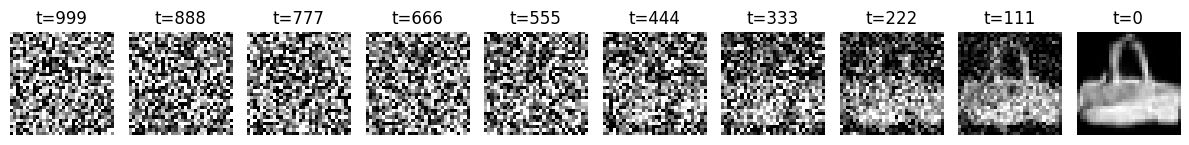

Class 9: Ankle boot


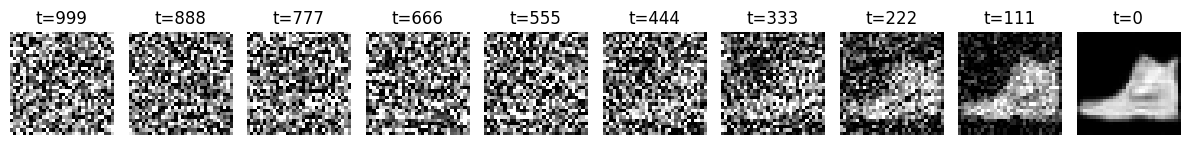

In [20]:
#@title Display Timestep Traces { display-mode: "form" }
vis_timesteps = torch.linspace(TIMESTEPS - 1, 0, 10).long().tolist()

for class_label in range(NUM_CLASSES):
    _, trace = denoising_process_single_sample(
        denoising_model, class_label=class_label, record_timesteps=vis_timesteps
    )
    trace_dict = {t: x_t for t, x_t in trace}
    imgs = [trace_dict[t].squeeze(0).cpu() for t in vis_timesteps]
    titles = [f"t={t}" for t in vis_timesteps]
    print(f"Class {class_label}: {CLASS_NAMES[class_label]}")
    utils.show_images(torch.stack(imgs), titles=titles)

---
## 7 🌐 Interactive Web App

Run the cell below to launch the full fashion magazine generator. It uses the trained DDPM model to generate images and an LLM (via your API key) for the article text — identical to the standalone fashion app.

In [21]:
API_KEY = "YOUR-LITE-LLM-API-KEY-HERE"  # @param {type:"string"}

In [22]:
#@title Run the Web App { display-mode: "form" }
REPO    = "eth-bmai-fs26/project"
BRANCH  = "week2-fashion-magazine-notebook/week2/notebook"


# ── 1. Download app_colab.py and dataset from GitHub ──────────────────────────

BASE_RAW = f"https://raw.githubusercontent.com/{REPO}/refs/heads/{BRANCH}"

subprocess.run(["curl", "-s", "-O", f"{BASE_RAW}/visualization/app_colab.py"], check=True)

os.makedirs("/content/Data", exist_ok=True)
subprocess.run(["curl", "-s", "-o", "/content/Data/fashion_data_2018_2022.xls",
                f"{BASE_RAW}/visualization/Data/fashion_data_2018_2022.xls"], check=True)

import importlib, app_colab

importlib.reload(app_colab)
print("app_colab.py loaded.")

# ── 2. Image generation — uses denoising_model trained in section 4 ──────────
def _generate_ddpm_image(class_label=0):
    generated = sample(denoising_model, num_samples=1, class_label=int(class_label) % NUM_CLASSES)
    generated = (generated.clamp(-1, 1) + 1) / 2.0
    return app_colab.tensor_to_b64(generated[0])

# ── 3. Launch — displays the app directly in this cell output ─────────────────
app_colab.register_all(
    generate_fn=_generate_ddpm_image,
    api_key=API_KEY,
    branch=BRANCH,
    repo=REPO,
)

app_colab.py loaded.
[app_colab] Loaded fashion data from /content/Data/fashion_data_2018_2022.xls


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/usr/local/lib/python3.12/dist-packages/httpx/_transports/default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_sync/connection_pool.py", line 256, in handle_request
    raise exc from None
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_sync/connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_sync/connection.py", line 101, in handle_request
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_sync/connection.py", line 78, in handle_request
    stream = self._connect(request)
             ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/loca

---
## 8 💬 Discussion

**The goal of this notebook was to teach you how to build a generative model from scratch.** You now understand how diffusion works end-to-end: how to corrupt data with noise, how to train a neural network to reverse that process, and how to sample new images from pure static.

Diffusion models are a novel and elegant way to generate data from complex, unknown distributions — the model never sees the true data distribution directly, yet learns to reproduce it by simply practicing to reverse noise.

As you experienced firsthand, even generating convincing 28×28 grayscale images requires careful tuning, significant training time, and meaningful compute. Scaling this up to the high-resolution, photorealistic outputs of models like Stable Diffusion requires orders of magnitude more of all three.

This raises a practical question every ML engineer faces: **build vs. use?**

- **Build your own** when you need full control, have domain-specific data, or want to deeply understand the system — as you just did.
- **Rely on a 3rd-party model** (via API) when quality, speed, and cost matter more than ownership — and when a strong pre-trained model already exists for your task.

In our fashion app, we *could* plug in the toy DDPM you just trained — but a production-grade API will produce far better images with far less effort. Knowing when to make that trade-off is a core skill in applied ML.

**Building the actual fashion editor app is the goal of the other part of this project.** There, you will act as the orchestrator — connecting image generation APIs, language models, and the rest of the pipeline to bring the full application to life!